# Decision Tree from Scratch


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_wine
from sklearn import tree
data = load_wine()
#convert to a dataframe
df = pd.DataFrame(data.data, columns = data.feature_names)
#create the species column
df['Class'] = data.target
#replace this with the actual names
target = np.unique(data.target)
target_names = np.unique(data.target_names)
targets = dict(zip(target, target_names))
df['Class'] = df['Class'].replace(targets)

In [3]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [4]:
#extract features and target variables
x = df.drop(columns="Class")
y = df["Class"]
#save the feature name and target variables
feature_names = x.columns
labels = y.unique()
#split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,
                                                 test_size = 0.3,
                                                 random_state = 42)

In [7]:
from collections import Counter

class Node:
    def __init__(self, left=None, right=None, feature_idx=None, threshold=None, value=None):
        self.left = left
        self.right = right
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, random_state, max_depth, min_samples_leaf, criterion=None):
        self.random_state = random_state
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        self.root = self.branch(X, y)

    def branch(self, X, y, depth=0):
        num_samples, num_features = X.shape
        # Return leaf node if we've reached the max depth, min samples, or only have prediction value left
        if depth >= self.max_depth or num_samples < self.min_samples_leaf or len(np.unique(y)) == 1:
            return Node(value=Counter(y).most_common(1)[0][0])

        feature_idx, threshold = self.select_threshold(X, y, num_features)
        
        left_idxs = np.nonzero(X[:, feature_idx] < threshold)[0]
        right_idxs = np.nonzero(X[:, feature_idx] >= threshold)[0]
        print(np.argwhere(X[:, feature_idx] > threshold).flatten())
        print(right_idxs)

        left_X, left_y = X[left_idxs], y[left_idxs]
        right_X, right_y = X[right_idxs], y[right_idxs]

        return Node(left=self.branch(left_X, left_y, depth=depth+1), right=self.branch(right_X, right_y, depth=depth+1), feature_idx=feature_idx, threshold=threshold)

    def select_threshold(self, X, y, num_features):
        max_info_gain = -1
        for feature_idx in range(num_features):
            print(feature_idx)
            print(X)
            feature_col = X[:, feature_idx]
            thresholds = np.unique(feature_col)
            for threshold in thresholds:
                info_gain = self.information_gain(feature_col, y, threshold)

                if info_gain > max_info_gain:
                    max_info_gain = info_gain
                    selected_feature_idx = feature_idx
                    selected_threshold = threshold
        return selected_feature_idx, selected_threshold

    def information_gain(self, feature_col, y, threshold):
        left_idxs = np.nonzero(feature_col < threshold)[0]
        right_idxs = np.nonzero(feature_col >= threshold)[0]

        y_entropy = self.entropy(y)
        left_entropy = self.entropy(y[left_idxs])
        right_entropy = self.entropy(y[right_idxs])

        return y_entropy - (len(left_idxs)/len(y) * left_entropy) - (len(right_idxs)/len(y) * right_entropy)

    def entropy(y):
        probs = np.bincount(y) / len(y)
        return -np.sum([p * np.log2(p) for p in probs])
    
    def predict(self, X):
        return [self.pred(x, self.root) for x in X]

    def pred(self, x, node):
        if node.value:
            return node.value
        
        if(x[node.feature_idx] < node.threshold):
            self.pred(x, node.left)
        else:
            self.pred(x, node.right)

In [8]:
# from sklearn.tree import DecisionTreeClassifier
#import relevant functions
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import export_text

clf_model = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=3, min_samples_leaf=5)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

# #export the decision rules
# tree_rules = export_text(clf_model,
#                         feature_names = list(feature_names))
# #print the result
# print(tree_rules)

print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))


InvalidIndexError: (slice(None, None, None), 0)

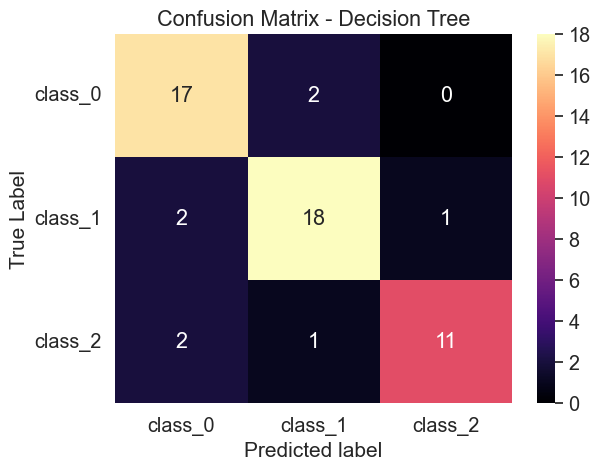

<Figure size 1000x700 with 0 Axes>

In [ ]:
#import the relevant packages
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
#get the confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test,
                                            y_predict)
#turn this into a dataframe
matrix_df = pd.DataFrame(confusion_matrix)
#plot the result
ax = plt.axes()
sns.set(font_scale=1.3)
plt.figure(figsize=(10,7))
sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="magma")
#set axis titles
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel("Predicted label", fontsize =15)
ax.set_xticklabels(['']+labels)
ax.set_ylabel("True Label", fontsize=15)
ax.set_yticklabels(list(labels), rotation = 0)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import export_text

clf_model = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=1, min_samples_leaf=5)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

#export the decision rules
tree_rules = export_text(clf_model,
                        feature_names = list(feature_names))
#print the result
print(tree_rules)

print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))

|--- od280/od315_of_diluted_wines <= 2.19
|   |--- class: class_2
|--- od280/od315_of_diluted_wines >  2.19
|   |--- class: class_1

0.5555555555555556
0.6290322580645161


C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:757

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import export_text

clf_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5, random_state=42)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

#export the decision rules
tree_rules = export_text(clf_model,
                        feature_names = list(feature_names))
#print the result
print(tree_rules)
print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))

|--- od280/od315_of_diluted_wines <= 2.19
|   |--- hue <= 0.90
|   |   |--- flavanoids <= 1.24
|   |   |   |--- class: class_2
|   |   |--- flavanoids >  1.24
|   |   |   |--- class: class_2
|   |--- hue >  0.90
|   |   |--- class: class_1
|--- od280/od315_of_diluted_wines >  2.19
|   |--- alcohol <= 12.79
|   |   |--- class: class_1
|   |--- alcohol >  12.79
|   |   |--- color_intensity <= 3.82
|   |   |   |--- class: class_1
|   |   |--- color_intensity >  3.82
|   |   |   |--- class: class_0

0.8518518518518519
0.967741935483871


C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:757